In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score,cross_val_predict
from sklearn import svm
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from feature.selector import Selective, SelectionMethod
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

In [2]:
def numeric_columns(df):
    numeric_cols = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
    return numeric_cols
# Load dataset
df = pd.read_csv("12 features - no imp.csv")

# Use function to extract numeric columns
numeric_cols = numeric_columns(df)
# print(df_num.shape)
# print(df_num.columns)
# print(df_num['MHW_count'].value_counts())

# Create a copy of the DataFrame
df_numeric = df[numeric_cols].copy()

# Now you can safely modify df_numeric
#df_numeric['mhw_count'] = df_numeric['mhw_count'].astype(str)

df_numeric.loc[df_numeric['mhw_count'].isin([2, 3]), 'mhw_count'] = 2


print(df_numeric['mhw_count'].value_counts())

# Shuffle the DataFrame
shuffled_df_numeric = shuffle(df_numeric, random_state=42)

# Separate features (X) and labels (y) after shuffling
X = shuffled_df_numeric.drop(['mhw_count'], axis=1)
y = shuffled_df_numeric['mhw_count']
X.shape, y.shape

mhw_count
0    3245
1     663
2     158
Name: count, dtype: int64


((4066, 11), (4066,))

## KNN Imputation

In [30]:
nan = np.nan
imputer = KNNImputer()
imputed = imputer.fit_transform(shuffled_df_numeric)

In [31]:
imputed_df = pd.DataFrame(imputed, columns = shuffled_df_numeric.columns)
imputed_df

,ammonium,ammonium std,nitrite,nitrite std,nitrate,iron,nitrate std,radiation 8.1,radiation 30,sea surface temp grad,sea surface temp,mhw_count
0,0.011647,0.001062,0.006479,0.001361,4.039602,0.000004,1.021912,46.347424,45.408386,0.245140,26.686632,0.0
1,0.019421,0.014966,0.036846,0.047819,5.954987,0.000003,1.244382,50.930030,54.287350,0.167470,27.159315,0.0
2,0.012506,0.006803,0.005806,0.004141,0.003165,0.000805,0.002556,52.996185,53.979880,2.000300,24.200793,0.0
3,0.040871,0.012805,0.175246,0.095507,11.336968,0.000004,1.000068,40.447495,43.392790,2.105800,18.466765,0.0
4,0.025083,0.011750,0.054778,0.047893,6.231764,0.000002,0.853389,46.940914,45.790096,0.093639,26.730190,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4061,0.012845,0.000930,0.029691,0.004530,0.012457,0.001244,0.004551,47.209393,43.349780,0.255560,23.675053,1.0
4062,0.012506,0.006803,0.005806,0.004141,0.003165,0.000805,0.002556,52.275124,54.200054,2.000300,24.192727,0.0
4063,0.012245,0.000652,0.002289,0.000248,0.014058,0.001074,0.004599,41.299805,41.682808,0.282200,29.767761,1.0
4064,0.014199,0.009693,0.025725,0.011551,8.367322,0.000990,3.924304,30.019270,30.199345,1.140200,4.301265,0.0


In [32]:
# Shuffle the DataFrame
shuffled_imp = shuffle(imputed_df, random_state=42)

# Separate features (X) and labels (y) after shuffling
X_imp = shuffled_imp.drop(['mhw_count'], axis=1)
y_imp = shuffled_imp['mhw_count']

## First classifier KNN imputation

(3252, 11) (3252,) (814, 11) (814,)
cross validation scores: [0.96805897 0.96186962 0.96678967 0.97416974 0.96063961]
0.9663 accuracy with a standard deviation of 0.0048
Accuracy: 97.54%
[[642   7   1]
 [ 10 122   1]
 [  1   0  30]]
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99       650
         1.0       0.95      0.92      0.93       133
         2.0       0.94      0.97      0.95        31

    accuracy                           0.98       814
   macro avg       0.96      0.96      0.96       814
weighted avg       0.98      0.98      0.98       814



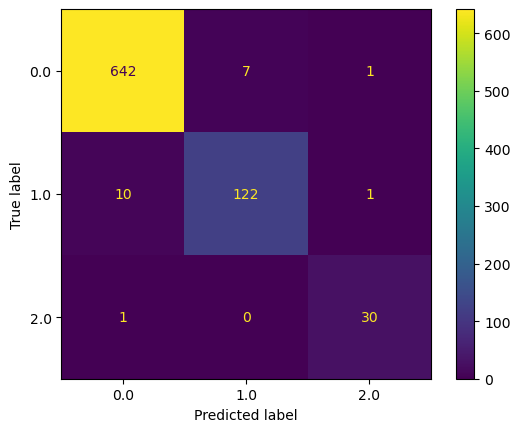

In [33]:
X_train_KNN, X_test, y_train_KNN, y_test = train_test_split(
    X_imp, y_imp, stratify = y_imp, test_size=0.2, random_state=42)

print(X_train_KNN.shape, y_train_KNN.shape,
X_test.shape, y_test.shape)

KNN_KNN = KNeighborsClassifier()
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNN_KNN)]
)
clf.fit(X_train_KNN, y_train_KNN)

cross_val_scores = cross_val_score(clf, X_imp, y_imp, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = clf.predict(X_test)
prob_pred = clf.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(cm)
#disp = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'pred')
#disp_2 = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'true')
disp_3 = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
#disp_2.plot()
print(classification_report(y_test, y_pred))

## Distancebased KNN

In [45]:
nan = np.nan
imputer = KNNImputer(weights = 'distance')
imputed = imputer.fit_transform(shuffled_df_numeric)
imputed_df_dis = pd.DataFrame(imputed, columns = shuffled_df_numeric.columns)
imputed_df_dis

,ammonium,ammonium std,nitrite,nitrite std,nitrate,iron,nitrate std,radiation 8.1,radiation 30,sea surface temp grad,sea surface temp,mhw_count
0,0.011647,0.001062,0.006479,0.001361,4.039602,0.000004,1.021912,46.347424,45.408386,0.245140,26.686632,0.0
1,0.019421,0.014966,0.036846,0.047819,5.954987,0.000003,1.244382,50.930030,54.287350,0.167470,27.159315,0.0
2,0.012506,0.006803,0.005806,0.004141,0.003165,0.000805,0.002556,52.996185,53.979880,2.000300,24.200793,0.0
3,0.040871,0.012805,0.175246,0.095507,11.336968,0.000004,1.000068,40.447495,43.392790,2.105800,18.466765,0.0
4,0.025083,0.011750,0.054778,0.047893,6.231764,0.000002,0.853389,46.940914,45.790096,0.093511,26.730190,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4061,0.012845,0.000930,0.029691,0.004530,0.012457,0.001244,0.004551,47.209393,43.349780,0.255560,23.675053,1.0
4062,0.012506,0.006803,0.005806,0.004141,0.003165,0.000805,0.002556,52.275124,54.200054,2.000300,24.192727,0.0
4063,0.012245,0.000652,0.002289,0.000248,0.014058,0.001074,0.004599,41.299805,41.682808,0.282200,29.767761,1.0
4064,0.014199,0.009693,0.025725,0.011551,8.367322,0.000990,3.924304,30.019270,30.199345,1.140200,4.301265,0.0


In [46]:
# Shuffle the DataFrame
shuffled_imp_dis = shuffle(imputed_df_dis, random_state=42)

# Separate features (X) and labels (y) after shuffling
X_imp_dis = shuffled_imp_dis.drop(['mhw_count'], axis=1)
y_imp_dis = shuffled_imp_dis['mhw_count']

(3252, 11) (3252,) (814, 11) (814,)
cross validation scores: [0.96683047 0.96186962 0.96432964 0.97170972 0.95940959]
0.9648 accuracy with a standard deviation of 0.0042
Accuracy: 97.42%
[[640   8   2]
 [  9 123   1]
 [  1   0  30]]
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98       650
         1.0       0.94      0.92      0.93       133
         2.0       0.91      0.97      0.94        31

    accuracy                           0.97       814
   macro avg       0.94      0.96      0.95       814
weighted avg       0.97      0.97      0.97       814



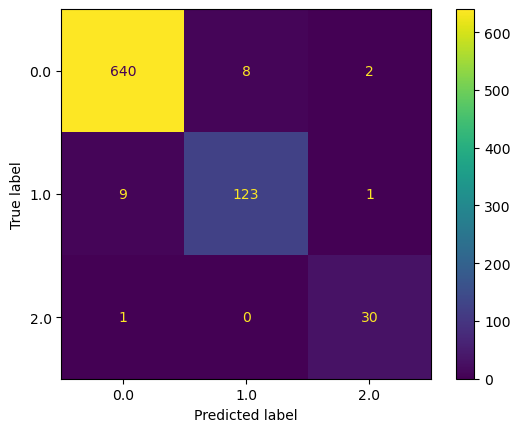

In [47]:
X_train_dis, X_test, y_train_dis, y_test = train_test_split(
    X_imp_dis, y_imp_dis, stratify = y_imp_dis, test_size=0.2, random_state=42)

print(X_train_dis.shape, y_train_dis.shape,
X_test.shape, y_test.shape)

KNN_dis = KNeighborsClassifier()
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNN_dis)]
)
clf.fit(X_train_dis, y_train_dis)

cross_val_scores = cross_val_score(clf, X_imp_dis, y_imp_dis, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = clf.predict(X_test)
prob_pred = clf.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(cm)
#disp = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'pred')
#disp_2 = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'true')
disp_3 = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
#disp_2.plot()
print(classification_report(y_test, y_pred))

## Different values uniform

In [66]:
nan = np.nan
imputer = KNNImputer(n_neighbors = 9)
imputed = imputer.fit_transform(shuffled_df_numeric)
imputed_df_dif = pd.DataFrame(imputed, columns = shuffled_df_numeric.columns)
imputed_df_dif

,ammonium,ammonium std,nitrite,nitrite std,nitrate,iron,nitrate std,radiation 8.1,radiation 30,sea surface temp grad,sea surface temp,mhw_count
0,0.011647,0.001062,0.006479,0.001361,4.039602,0.000004,1.021912,46.347424,45.408386,0.245140,26.686632,0.0
1,0.019421,0.014966,0.036846,0.047819,5.954987,0.000003,1.244382,50.930030,54.287350,0.167470,27.159315,0.0
2,0.012506,0.006803,0.005806,0.004141,0.003165,0.000805,0.002556,52.996185,53.979880,2.000300,24.200793,0.0
3,0.040871,0.012805,0.175246,0.095507,11.336968,0.000004,1.000068,40.447495,43.392790,2.105800,18.466765,0.0
4,0.025083,0.011750,0.054778,0.047893,6.231764,0.000002,0.853389,46.940914,45.790096,0.094916,26.730190,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4061,0.012845,0.000930,0.029691,0.004530,0.012457,0.001244,0.004551,47.209393,43.349780,0.255560,23.675053,1.0
4062,0.012506,0.006803,0.005806,0.004141,0.003165,0.000805,0.002556,52.275124,54.200054,2.000300,24.192727,0.0
4063,0.012245,0.000652,0.002289,0.000248,0.014058,0.001074,0.004599,41.299805,41.682808,0.282200,29.767761,1.0
4064,0.014199,0.009693,0.025725,0.011551,8.367322,0.000990,3.924304,30.019270,30.199345,1.077687,4.301265,0.0


In [67]:
# Shuffle the DataFrame
shuffled_imp_dif = shuffle(imputed_df_dif, random_state=42)

# Separate features (X) and labels (y) after shuffling
X_imp_dif = shuffled_imp_dif.drop(['mhw_count'], axis=1)
y_imp_dif = shuffled_imp_dif['mhw_count']

(3252, 11) (3252,) (814, 11) (814,)
cross validation scores: [0.96314496 0.96063961 0.97170972 0.9803198  0.96432964]
0.9680 accuracy with a standard deviation of 0.0072
Accuracy: 97.67%
[[644   6   0]
 [ 10 121   2]
 [  1   0  30]]
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99       650
         1.0       0.95      0.91      0.93       133
         2.0       0.94      0.97      0.95        31

    accuracy                           0.98       814
   macro avg       0.96      0.96      0.96       814
weighted avg       0.98      0.98      0.98       814



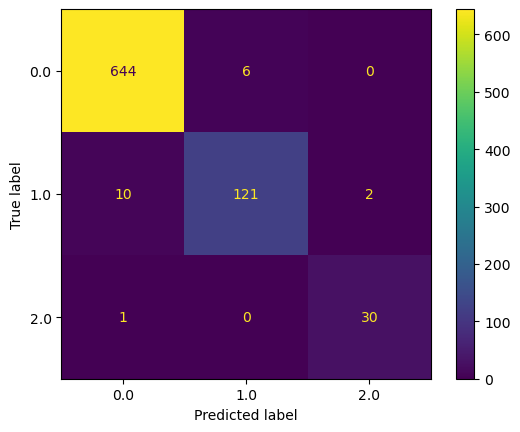

In [68]:
X_train_dif, X_test, y_train_dif, y_test = train_test_split(
    X_imp_dif, y_imp_dif, stratify = y_imp_dif, test_size=0.2, random_state=42)

print(X_train_dif.shape, y_train_dif.shape,
X_test.shape, y_test.shape)

KNN_dif = KNeighborsClassifier()
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNN_dif)]
)
clf.fit(X_train_dif, y_train_dif)

cross_val_scores = cross_val_score(clf, X_imp_dif, y_imp_dif, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = clf.predict(X_test)
prob_pred = clf.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(cm)
#disp = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'pred')
#disp_2 = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'true')
disp_3 = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
#disp_2.plot()
print(classification_report(y_test, y_pred))

## Median imputation

In [81]:
med_imp = shuffled_df_numeric.fillna(shuffled_df_numeric.median())
# Shuffle the DataFrame
shuffled_med = shuffle(med_imp, random_state=42)

# Separate features (X) and labels (y) after shuffling
X_med = shuffled_med.drop(['mhw_count'], axis=1)
y_med = shuffled_med['mhw_count']

## Median classifier

cross validation scores: [0.96437346 0.96186962 0.96063961 0.97539975 0.95817958]
0.9641 accuracy with a standard deviation of 0.0060
Accuracy: 97.42%
[[644   6   0]
 [ 12 120   1]
 [  2   0  29]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       650
           1       0.95      0.90      0.93       133
           2       0.97      0.94      0.95        31

    accuracy                           0.97       814
   macro avg       0.97      0.94      0.95       814
weighted avg       0.97      0.97      0.97       814



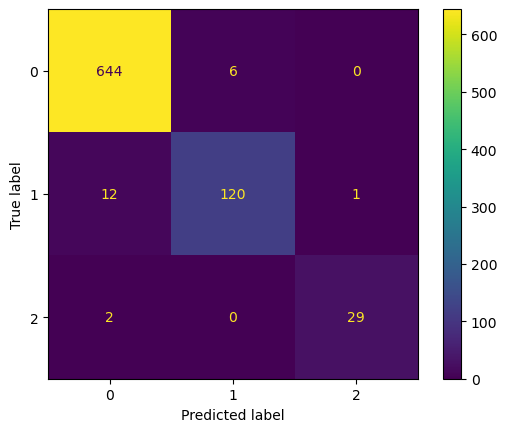

In [82]:
X_train_med, X_test, y_train_med, y_test = train_test_split(
    X_med, y_med, stratify = y_med, test_size=0.2, random_state=42)

X_train_med.shape, y_train_med.shape
X_test.shape, y_test.shape

KNN_med = KNeighborsClassifier()
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNN_med)]
)
clf.fit(X_train_med, y_train_med)

cross_val_scores = cross_val_score(clf, X_med, y_med, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = clf.predict(X_test)
prob_pred = clf.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(cm)
#disp = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'pred')
#disp_2 = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'true')
disp_3 = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
#disp_2.plot()
print(classification_report(y_test, y_pred))

## Mean imputation

In [83]:
mean_imp = shuffled_df_numeric.fillna(shuffled_df_numeric.mean())
# Shuffle the DataFrame
shuffled_mean = shuffle(mean_imp, random_state=42)

# Separate features (X) and labels (y) after shuffling
X_mean = shuffled_mean.drop(['mhw_count'], axis=1)
y_mean = shuffled_mean['mhw_count']

## Mean Classifier

cross validation scores: [0.96191646 0.95817958 0.96432964 0.97293973 0.95817958]
0.9631 accuracy with a standard deviation of 0.0054
Accuracy: 97.05%
[[642   8   0]
 [ 13 119   1]
 [  2   0  29]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       650
           1       0.94      0.89      0.92       133
           2       0.97      0.94      0.95        31

    accuracy                           0.97       814
   macro avg       0.96      0.94      0.95       814
weighted avg       0.97      0.97      0.97       814



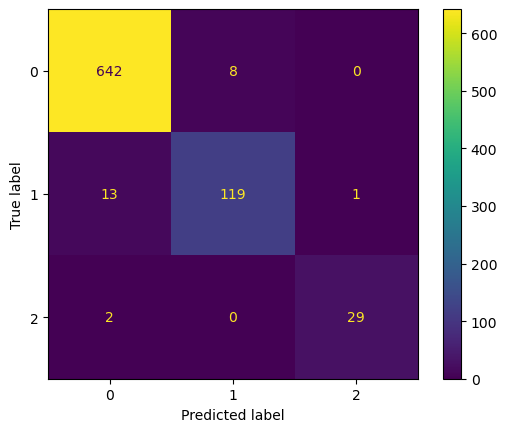

In [84]:
X_train_mean, X_test, y_train_mean, y_test = train_test_split(
    X_mean, y_mean, stratify = y_mean, test_size=0.2, random_state=42)

X_train_mean.shape, y_train_mean.shape
X_test.shape, y_test.shape

KNN_mean = KNeighborsClassifier()
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNN_mean)]
)
clf.fit(X_train_mean, y_train_mean)

cross_val_scores = cross_val_score(clf, X_mean, y_mean, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = clf.predict(X_test)
prob_pred = clf.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(cm)
#disp = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'pred')
#disp_2 = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'true')
disp_3 = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
#disp_2.plot()
print(classification_report(y_test, y_pred))

## Grid Search KNN imputer

In [70]:
param_grid = [
     {'n_neighbors': [2, 3, 4, 5, 6, 7, 8, 9, 10],
      'weights': ['uniform', 'distance']
     }
]

grid = GridSearchCV(KNN_dif, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train_dif, y_train_dif)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
the best score was 0.9674073023750444
the best parameters were {'n_neighbors': 6, 'weights': 'distance'}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002091,0.002563,0.035355,0.008052,2,uniform,"{'n_neighbors': 2, 'weights': 'uniform'}",0.935484,0.953917,0.960000,0.949231,0.967692,0.953265,0.010829,13
1,0.006730,0.001756,0.005374,0.002016,2,distance,"{'n_neighbors': 2, 'weights': 'distance'}",0.952381,0.949309,0.964615,0.949231,0.973846,0.957876,0.009786,10
2,0.001568,0.001933,0.030463,0.005566,3,uniform,"{'n_neighbors': 3, 'weights': 'uniform'}",0.944700,0.963134,0.972308,0.949231,0.963077,0.958490,0.010094,9
3,0.008851,0.006962,0.000629,0.001259,3,distance,"{'n_neighbors': 3, 'weights': 'distance'}",0.953917,0.969278,0.972308,0.958462,0.972308,0.965254,0.007621,7
4,0.003229,0.006458,0.032236,0.000436,4,uniform,"{'n_neighbors': 4, 'weights': 'uniform'}",0.944700,0.958525,0.972308,0.944615,0.956923,0.955414,0.010283,11
5,0.003488,0.001814,0.005645,0.005037,4,distance,"{'n_neighbors': 4, 'weights': 'distance'}",0.955453,0.967742,0.973846,0.953846,0.973846,0.964947,0.008713,8
6,0.001913,0.002347,0.031728,0.008486,5,uniform,"{'n_neighbors': 5, 'weights': 'uniform'}",0.943164,0.960061,0.967692,0.941538,0.956923,0.953876,0.010054,12
7,0.006335,0.004913,0.007588,0.005541,5,distance,"{'n_neighbors': 5, 'weights': 'distance'}",0.953917,0.969278,0.972308,0.961538,0.973846,0.966177,0.007454,4
8,0.007160,0.004319,0.028052,0.004572,6,uniform,"{'n_neighbors': 6, 'weights': 'uniform'}",0.923195,0.960061,0.964615,0.938462,0.950769,0.947421,0.015059,14
9,0.004428,0.000417,0.005731,0.001091,6,distance,"{'n_neighbors': 6, 'weights': 'distance'}",0.956989,0.969278,0.975385,0.961538,0.973846,0.967407,0.007093,1


## GridSearch median

In [85]:
param_grid = [
     {'n_neighbors': [2, 3, 4, 5, 6, 7, 8, 9, 10],
      'weights': ['uniform', 'distance']
     }
]

grid = GridSearchCV(KNN_med, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train_med, y_train_med)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
the best score was 0.9646390168970814
the best parameters were {'n_neighbors': 6, 'weights': 'distance'}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004412,0.002354,0.032257,0.004813,2,uniform,"{'n_neighbors': 2, 'weights': 'uniform'}",0.938556,0.950845,0.960000,0.946154,0.967692,0.952649,0.010241,13
1,0.004208,0.002115,0.004278,0.002935,2,distance,"{'n_neighbors': 2, 'weights': 'distance'}",0.953917,0.947773,0.963077,0.946154,0.972308,0.956646,0.009828,9
2,0.004776,0.005837,0.027848,0.007519,3,uniform,"{'n_neighbors': 3, 'weights': 'uniform'}",0.947773,0.960061,0.966154,0.947692,0.958462,0.956028,0.007244,10
3,0.006527,0.002572,0.002354,0.001448,3,distance,"{'n_neighbors': 3, 'weights': 'distance'}",0.956989,0.964670,0.969231,0.955385,0.970769,0.963409,0.006249,7
4,0.005562,0.000782,0.028851,0.000969,4,uniform,"{'n_neighbors': 4, 'weights': 'uniform'}",0.947773,0.956989,0.969231,0.943077,0.953846,0.954183,0.008932,11
5,0.003908,0.000126,0.005567,0.000783,4,distance,"{'n_neighbors': 4, 'weights': 'distance'}",0.958525,0.966206,0.970769,0.953846,0.969231,0.963715,0.006492,6
6,0.008981,0.005699,0.022813,0.007089,5,uniform,"{'n_neighbors': 5, 'weights': 'uniform'}",0.946237,0.958525,0.972308,0.935385,0.952308,0.952952,0.012327,12
7,0.003184,0.006368,0.006436,0.007882,5,distance,"{'n_neighbors': 5, 'weights': 'distance'}",0.953917,0.966206,0.973846,0.955385,0.970769,0.964025,0.008044,4
8,0.009872,0.008077,0.026084,0.009017,6,uniform,"{'n_neighbors': 6, 'weights': 'uniform'}",0.923195,0.958525,0.969231,0.932308,0.946154,0.945883,0.016757,14
9,0.002822,0.002426,0.008226,0.009512,6,distance,"{'n_neighbors': 6, 'weights': 'distance'}",0.955453,0.967742,0.975385,0.953846,0.970769,0.964639,0.008527,1


## GridSearch mean

In [87]:
param_grid = [
     {'n_neighbors': [2, 3, 4, 5, 6, 7, 8, 9, 10],
      'weights': ['uniform', 'distance']
     }
]

grid = GridSearchCV(KNN_mean, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train_mean, y_train_mean)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
the best score was 0.9664842254519673
the best parameters were {'n_neighbors': 5, 'weights': 'distance'}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.007638,0.004936,0.034240,0.007079,2,uniform,"{'n_neighbors': 2, 'weights': 'uniform'}",0.938556,0.953917,0.980000,0.940000,0.966154,0.955725,0.015769,12
1,0.008989,0.006822,0.003625,0.001874,2,distance,"{'n_neighbors': 2, 'weights': 'distance'}",0.949309,0.952381,0.976923,0.946154,0.975385,0.960030,0.013320,10
2,0.004134,0.004074,0.031607,0.004794,3,uniform,"{'n_neighbors': 3, 'weights': 'uniform'}",0.949309,0.961598,0.978462,0.947692,0.966154,0.960643,0.011358,9
3,0.006110,0.005983,0.003451,0.003173,3,distance,"{'n_neighbors': 3, 'weights': 'distance'}",0.956989,0.967742,0.975385,0.950769,0.970769,0.964331,0.009089,6
4,0.003846,0.006092,0.031248,0.007335,4,uniform,"{'n_neighbors': 4, 'weights': 'uniform'}",0.947773,0.958525,0.978462,0.941538,0.964615,0.958183,0.012947,11
5,0.002651,0.005302,0.003162,0.006325,4,distance,"{'n_neighbors': 4, 'weights': 'distance'}",0.958525,0.967742,0.975385,0.950769,0.972308,0.964946,0.009090,4
6,0.003226,0.006453,0.031967,0.000256,5,uniform,"{'n_neighbors': 5, 'weights': 'uniform'}",0.949309,0.955453,0.975385,0.936923,0.960000,0.955414,0.012642,13
7,0.006315,0.007734,0.003153,0.006306,5,distance,"{'n_neighbors': 5, 'weights': 'distance'}",0.956989,0.969278,0.978462,0.955385,0.972308,0.966484,0.008928,1
8,0.003579,0.007158,0.031422,0.000459,6,uniform,"{'n_neighbors': 6, 'weights': 'uniform'}",0.932412,0.955453,0.969231,0.933846,0.956923,0.949573,0.014261,14
9,0.005183,0.005906,0.005401,0.006176,6,distance,"{'n_neighbors': 6, 'weights': 'distance'}",0.960061,0.969278,0.976923,0.953846,0.972308,0.966483,0.008386,2


## Best Classifier KNN Imputer

(3252, 11) (3252,) (814, 11) (814,)
cross validation scores: [0.96805897 0.96309963 0.96801968 0.98523985 0.9704797 ]
0.9710 accuracy with a standard deviation of 0.0075
Accuracy: 97.79%
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99       650
         1.0       0.97      0.91      0.94       133
         2.0       0.94      0.94      0.94        31

    accuracy                           0.98       814
   macro avg       0.96      0.95      0.95       814
weighted avg       0.98      0.98      0.98       814



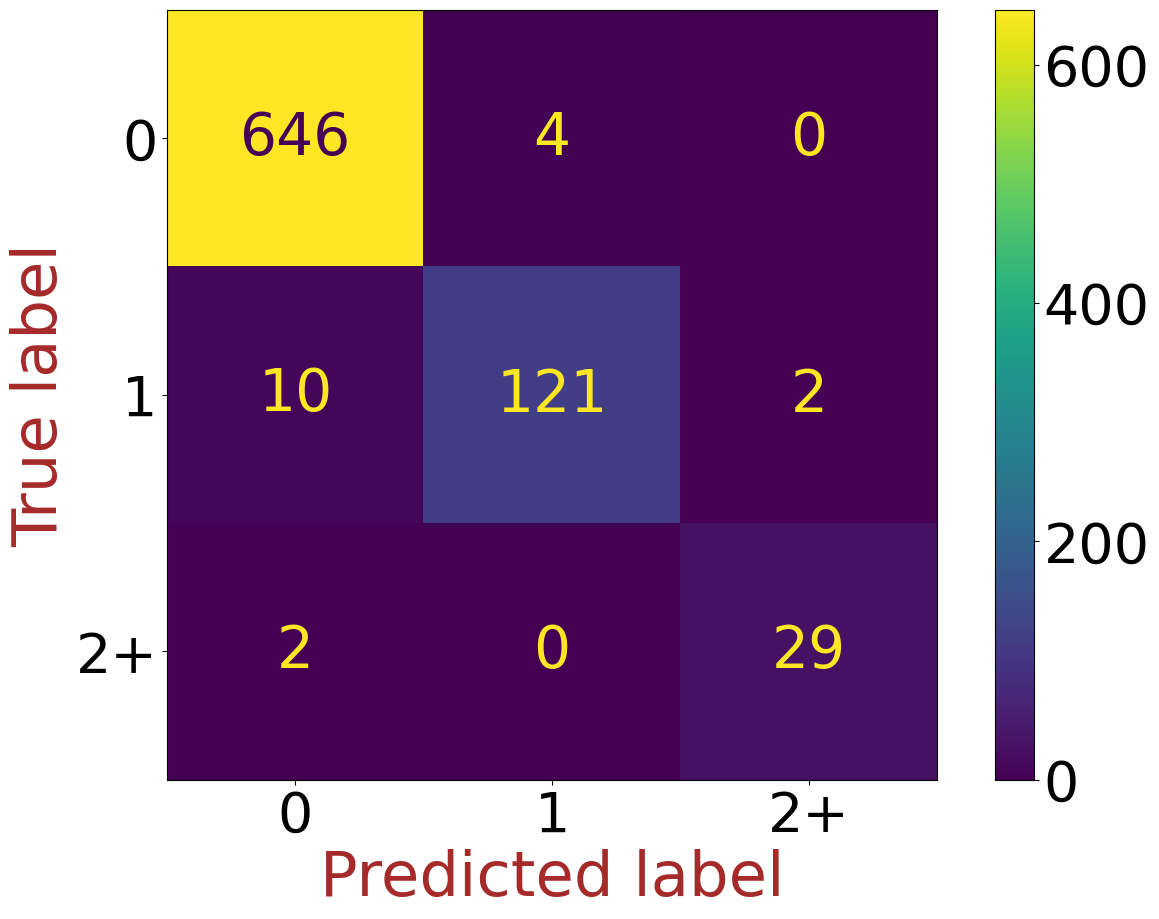

In [88]:
X_train_dif, X_test, y_train_dif, y_test = train_test_split(
    X_imp_dif, y_imp_dif, stratify = y_imp_dif, test_size=0.2, random_state=42)

print(X_train_dif.shape, y_train_dif.shape,
X_test.shape, y_test.shape)

KNN_dif = KNeighborsClassifier(n_neighbors = 6, weights = 'distance')
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNN_dif)]
)
clf.fit(X_train_dif, y_train_dif)

cross_val_scores = cross_val_score(clf, X_imp_dif, y_imp_dif, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = clf.predict(X_test)
prob_pred = clf.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

#cm = confusion_matrix(y_test, y_pred)
#print(cm)
#disp = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'pred')
#disp_2 = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'true')
f,ax = plt.subplots(1,1,figsize=(15,10))
disp_3 = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, display_labels=['0', '1', '2+'], ax = ax, values_format= '.9g', colorbar = False)

# Change fontsize of values in the matrix
for text in disp_3.text_.ravel():
    text.set_fontsize(42)  # Set your desired fontsize here

# Add colorbar and adjust its font size (only if you want it)
cbar = plt.colorbar(disp_3.im_, ax=ax)
cbar.ax.tick_params(labelsize=40)  # Set colorbar tick label size

plt.xlabel('Predicted label', fontsize=45, color='brown')  
plt.ylabel('True label', fontsize=45, color='brown') 
#plt.title('KNN Classifier #1', fontsize=50) 

plt.xticks(fontsize=40)
plt.yticks(fontsize=40)

plt.savefig('KNN_conf.pdf', bbox_inches = 'tight')
#disp_2.plot()
print(classification_report(y_test, y_pred))

## LIME

In [13]:
from lime.lime_tabular import LimeTabularExplainer
# Create the explainer
explainer = LimeTabularExplainer(X_imp.values, 
                                   feature_names=X_imp.columns, 
                                   class_names=['rings'], 
                                   mode='classification',
                                 discretize_continuous = False,
                                   random_state=42)

In [14]:
# Get explanation for first row
exp = explainer.explain_instance(X_imp.iloc[0], 
                                 clf.predict, 
                                labels=X_imp.columns)

#Display explanation
exp.show_in_notebook(show_table=True)

exp.save_to_file('explanation_1.html')

C:\Users\hamid\anaconda3\envs\fsenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


NotImplementedError: LIME does not currently support classifier models without probability scores. If this conflicts with your use case, please let us know: https://github.com/datascienceinc/lime/issues/16

In [ ]:
from lime.lime_tabular import LimeTabularExplainer
# Create the explainer
explainer = LimeTabularExplainer(X.values, 
                                   feature_names=X.columns, 
                                   class_names=['rings'], 
                                   mode='classification',
                                 kernel_width = 5,
                                 discretize_continuous = False,
                                 verbose = True,                                
                                   random_state=42)